In [1]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from tqdm import tqdm
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
random.seed(42)

In [2]:
high_level_diseases = {
    # top level of MONDO hierarchy
    "acute disease": "MONDO_0020683", # (392)
    "auditory system disorder": "MONDO_0002409", # (345)
    "breast disorder": "MONDO_0002657", # (184)
    "cancer or benign tumor": "MONDO_0045024", # (4,709)
    "cardiovascular disorder": "MONDO_0004995", # (1,609)
    "chromosomal disorder": "MONDO_0019040", # (581)
    "connective tissue disorder": "MONDO_0003900", # (894)
    "digestive system disorder": "MONDO_0004335", # (1,390)
    # "disease related to transplantation": "MONDO_0700220", # (8)
    "disorder of development or morphogenesis": "MONDO_0021147", # (3,735)
    "disorder of orbital region": "MONDO_0002022", # (1,573)
    "disorder of visual system": "MONDO_0024458", # (1,676)
    "endocrine system disorder": "MONDO_0005151", # (1,641)
    "hematologic disorder": "MONDO_0005570", # (1,291)
    # "hereditary disease": "MONDO_0003847", # (11,433)
    # "iatrogenic disease": "MONDO_0043543", # (4)
    # "idiopathic disease": "MONDO_0700007", # (165)
    "immune system disorder": "MONDO_0005046", # (1,519)
    "infectious disease": "MONDO_0005550", # (1,070)
    "inflammatory disease": "MONDO_0021166", # (1,202)
    "integumentary system disorder": "MONDO_0002051", # (1,681)
    "metabolic disease": "MONDO_0005066", # (2,234)
    "mitochondrial disease": "MONDO_0044970", # (368)
    "mouth disorder": "MONDO_0006858", # (303)
    "musculoskeletal system disorder": "MONDO_0002081", # (3,112)
    "nervous system disorder": "MONDO_0005071", # (5,530)
    "nutritional disorder": "MONDO_0005137", # (109)
    "obstetric disorder": "MONDO_0700003", # (75)
    # "occupational disorder": "MONDO_0100366", # (6)
    "otorhinolaryngologic disease": "MONDO_0024623", # (368)
    # "perinatal disease": "MONDO_0100086", # (1)
    "poisoning": "MONDO_0029000", # (70)
    "post-infectious disorder": "MONDO_0021669", # (158)
    "premature aging syndrome": "MONDO_0019303", # (72)
    "psychiatric disorder": "MONDO_0002025", # (1,452)
    "radiation-induced disorder": "MONDO_0043459", # (20)
    "reproductive system disorder": "MONDO_0005039", # (1,450)
    "respiratory system disorder": "MONDO_0005087", # (788)
    # "syndromic disease": "MONDO_0002254", # (3,238)
    "ulcer disease": "MONDO_0043839", # (16)
    "upper digestive tract disorder": "MONDO_0044991", # (73)
    "urinary system disorder": "MONDO_0002118", # (766)

    # top level of EFO hierarchy
    # "animal disease", # (60)
    "breast disease": "EFO_0009483", # (121)
    "cardiovascular disease": "EFO_0000319", # (1,149)
    "chronic disease": "EFO_0009714", # (172)
    # "complication", # (7)
    "connective tissue disease": "EFO_1001986", # (674)
    "digestive system disease": "EFO_0000405", # (1,414)
    "endocrine system disease": "EFO_0001379", # (1,405)
    # "genetic disorder", # (9,592)
    "head and neck disorder": "EFO_0000524", # (1,568)
    "hematologic disease": "EFO_0005803", # (1,007)
    "immune system disease": "EFO_0000540", # (1,174)
    "infectious disease": "EFO_0005741", # (800)
    "inflammatory disease": "EFO_0009903", # (784)
    "integumentary system disease": "EFO_0010285", # (1,348)
    "intestinal disease": "EFO_0009431", # (409)
    "metabolic disease": "EFO_0000589", # (2,077)
    "musculoskeletal system disease": "EFO_0009676", # (2,893)
    "nervous system disease": "EFO_0000618", # (4,125)
    # "perinatal disease", # (21)
    # "perineum disease", # (1)
    # "photosensitivity disease", # (4)
    # "poisoning", # (15)
    # "radiation-induced disorder", # (16)
    "reproductive system disease": "EFO_0000512", # (1,125)
    "respiratory system disease": "EFO_0000684", # (561)
    # "soft tissue disease", # (1)
    # "sudden infant death syndrome", # (1)
    "urinary system disease": "EFO_0009690", # (645)
    "urogenital neoplasm": "EFO_0003863", # (69)
}

In [3]:
# cut offs for 90% of the nodes
pesto_cutoff = 70
plddt_cutoff = 70

if pesto_cutoff == 80:
    modality_cutoff = {
        "protein": 0.998,
        "lipid": 0.996,
        "nucleic_acid": 0.996,
        "ligand": 0.989,
        "ion": 0.989,
    }
elif pesto_cutoff == 70:
    modality_cutoff = {
        "protein": 0.998,
        "lipid": 0.996,
        "nucleic_acid": 0.996,
        "ligand": 0.993,
        "ion": 0.988,
    }
else:
    raise NotImplementedError("not implemented for this plddt cutoff")

modality_graphs = {}

for modality, cutoff in modality_cutoff.items():
    # with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_3_epoch10_step63085/embeddings_non_disease_PeSTo_80_{modality}.pkl", "rb") as f:
    #     non_disease_embeddings = pickle.load(f)

    # with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_3_epoch10_step63085/embeddings_PeSTo_80_{modality}.pkl", "rb") as f:
    #     disease_embeddings = pickle.load(f)

    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl", "rb") as f:
        embeddings_dataset = pickle.load(f)

    embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
    uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}

    similarity_matrix = cosine_similarity(embeddings)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    print(f"-----------------{modality}-----------------")
    print("Number of embeddings: ", embeddings.shape)
    print("num edges: ", filtered_indices[0].shape[0])

    G = nx.Graph()
    G.add_nodes_from(range(len(embeddings)))
    edges = zip(filtered_indices[0], filtered_indices[1], similarity_matrix[filtered_indices])
    G.add_weighted_edges_from(edges)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)
    print("size of largest connected component: ", size_of_largest_connected_component)
    print("proportion of largest connected component: ", size_of_largest_connected_component / len(embeddings))
    print("number of connected components", num_connected_components)
    print("density: ", whole_graph_density)
    print("clustering: ", whole_graph_clustering)
    print("average degree: ", np.mean([x[1] for x in G.degree()]))

    largest_component = max(nx.connected_components(G), key=len)
    largest_component_subgraph = G.subgraph(largest_component).copy()
    G = largest_component_subgraph

    adjacency_matrix = similarity_matrix > cutoff
    adjacency_matrix = adjacency_matrix.astype(int)
    largest_component_indices = sorted(list(largest_component))
    largest_component_adj_matrix = adjacency_matrix[np.ix_(largest_component_indices, largest_component_indices)]

    modality_graphs[modality] = {
        "graph": G,
        "uniprot_to_node_idx": uniprot_to_node_idx,
        "largest_component": largest_component,
        "filtered_indices": filtered_indices,
        "adjacency_matrix": largest_component_adj_matrix,
    }

uniprots_in_modality = {}
modalities = ['protein', 'lipid', 'nucleic_acid', 'ligand', 'ion']
for modality in modalities:
    node_idx_to_uniprot = {v: k for k, v in modality_graphs[modality]['uniprot_to_node_idx'].items()}
    uniprots_in_modality[modality] = [node_idx_to_uniprot[x] for x in modality_graphs[modality]['largest_component']]

-----------------protein-----------------
Number of embeddings:  (17158, 32)
num edges:  261673
size of largest connected component:  15421
proportion of largest connected component:  0.8987644247581303
number of connected components 1394
density:  0.0017777917823615932
clustering:  0.41121885853388995
average degree:  30.501573609977854
-----------------lipid-----------------
Number of embeddings:  (6766, 32)
num edges:  157164
size of largest connected component:  6072
proportion of largest connected component:  0.8974283180608927
number of connected components 541
density:  0.006867256590766537
clustering:  0.44944977239782463
average degree:  46.45699083653562
-----------------nucleic_acid-----------------
Number of embeddings:  (6649, 32)
num edges:  114405
size of largest connected component:  6031
proportion of largest connected component:  0.907053692284554
number of connected components 500
density:  0.005176397960009187
clustering:  0.4494694800899958
average degree:  34.4126

In [12]:
disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
disease_id_to_name = {x['diseaseId']: x['diseaseName'] for x in disease_associations[['diseaseId', 'diseaseName']].drop_duplicates().to_dict(orient='records')}
disease_associations = disease_associations[disease_associations.diseaseId.isin(high_level_diseases.values())]
top_level_diseases = disease_associations.groupby('diseaseId').filter(lambda x: len(x) > 100).diseaseId.unique()
print("Number of top level diseases: ", len(top_level_diseases))

top_disease_modality_df = []
for disease in top_level_diseases:
    row = {
        "disease": disease,
        "disease_name": disease_id_to_name[disease],
        "total_nodes": len(disease_associations[disease_associations.diseaseId == disease].uniprot_targetId),
    }
    for modality in modalities:
        uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
        disease_prots = set(uniprots_in_modality[modality]) & set(disease_associations[disease_associations.diseaseId == disease].uniprot_targetId)
        disease_nodes = set([uniprot_to_node_idx[x] for x in disease_prots])
        row[modality] = len(disease_nodes)
        G = modality_graphs[modality]['graph']
        G_disease = G.subgraph(disease_nodes).copy()
        largest_pathway_connected_component = max(nx.connected_components(G_disease), key=len)
        row[f"{modality}_LCC"] = len(largest_pathway_connected_component)
        row[f"{modality}_LCC_proportion"] = len(largest_pathway_connected_component) / len(disease_nodes)
    top_disease_modality_df.append(row)
top_disease_modality_df = pd.DataFrame(top_disease_modality_df)
top_disease_modality_df

Number of top level diseases:  20


,disease,disease_name,total_nodes,protein,protein_LCC,protein_LCC_proportion,lipid,lipid_LCC,lipid_LCC_proportion,nucleic_acid,nucleic_acid_LCC,nucleic_acid_LCC_proportion,ligand,ligand_LCC,ligand_LCC_proportion,ion,ion_LCC,ion_LCC_proportion
0,EFO_0005741,infectious disease,633,512,72,0.140625,193,36,0.186528,203,46,0.226601,159,71,0.446541,167,82,0.491018
1,EFO_0000540,immune system disease,1104,850,205,0.241176,391,140,0.358056,399,96,0.240602,384,276,0.718750,429,263,0.613054
2,EFO_0000618,nervous system disease,4236,3328,2626,0.789062,1183,511,0.431953,1602,1421,0.887016,1342,1238,0.922504,1478,1103,0.746279
3,EFO_0009431,intestinal disease,476,364,31,0.085165,150,19,0.126667,216,13,0.060185,167,73,0.437126,174,92,0.528736
4,MONDO_0002025,psychiatric disorder,967,744,222,0.298387,415,189,0.455422,307,69,0.224756,298,191,0.640940,349,173,0.495702
5,EFO_1001986,connective tissue disease,504,379,16,0.042216,165,47,0.284848,199,14,0.070352,171,67,0.391813,205,107,0.521951
6,EFO_0005803,hematologic disease,869,636,73,0.114780,233,58,0.248927,353,76,0.215297,335,245,0.731343,331,194,0.586103
7,MONDO_0700003,obstetric disorder,115,102,4,0.039216,77,11,0.142857,23,3,0.130435,22,4,0.181818,29,11,0.379310
8,MONDO_0045024,cancer or benign tumor,1460,1131,413,0.365164,451,155,0.343681,574,150,0.261324,484,388,0.801653,522,346,0.662835
9,MONDO_0044970,mitochondrial disease,231,188,9,0.047872,72,11,0.152778,55,3,0.054545,92,6,0.065217,73,14,0.191781


In [14]:
modality='ion'
top_disease_modality_df[['disease_name', 'total_nodes', modality, f"{modality}_LCC", f"{modality}_LCC_proportion"]].sort_values(f"{modality}_LCC_proportion", ascending=False)

,disease_name,total_nodes,ion,ion_LCC,ion_LCC_proportion
2,nervous system disease,4236,1478,1103,0.746279
17,endocrine system disease,1162,421,281,0.667458
8,cancer or benign tumor,1460,522,346,0.662835
18,metabolic disease,1518,515,328,0.636893
12,musculoskeletal system disease,1563,573,360,0.628272
1,immune system disease,1104,429,263,0.613054
11,reproductive system disease,1089,352,214,0.607955
6,hematologic disease,869,331,194,0.586103
16,cardiovascular disease,854,326,190,0.582822
19,integumentary system disease,1149,400,233,0.582500


In [6]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv", sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

In [17]:
for chosen_modality in modalities:
    G = modality_graphs[chosen_modality]['graph'].copy()
    uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
    largest_component = modality_graphs[chosen_modality]['largest_component']
    adjacency_matrix = modality_graphs[chosen_modality]['adjacency_matrix']

    node_information = []

    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    for chosen_disease in tqdm(top_level_diseases, desc=chosen_modality, total=len(top_level_diseases)):
        disease_name = disease_id_to_name[chosen_disease]
        disease_prots = set(uniprots_in_modality[chosen_modality]) & set(disease_associations[disease_associations.diseaseId == chosen_disease].uniprot_targetId)
        disease_nodes = set([uniprot_to_node_idx[x] for x in disease_prots])
        G_disease = G.subgraph(disease_nodes).copy()
        largest_pathway_connected_component = max(nx.connected_components(G_disease), key=len)
        print(disease_name, len(disease_nodes), len(largest_pathway_connected_component))
        for node in largest_component:
            if node in disease_nodes:
                G.nodes[node][disease_name] = 1
            else:
                G.nodes[node][disease_name] = 0

            if node in largest_pathway_connected_component:
                G.nodes[node][f"{disease_name}_LCC"] = 1
            else:
                G.nodes[node][f"{disease_name}_LCC"] = 0
        
    for node in largest_component:
        uniprot = node_idx_to_uniprot[node]
        gene = uniprot_to_gene.get(uniprot, "")
        G.nodes[node]['protein'] = uniprot
        G.nodes[node]['gene'] = gene
    nx.write_gexf(G, f'visualisation/{chosen_modality}_top_level_diseases.gexf')
    print(f"done writing gexf for {chosen_modality}")

protein:  15%|█▌        | 3/20 [00:00<00:01, 16.44it/s]

infectious disease 512 72
immune system disease 850 205
nervous system disease 3328 2626
intestinal disease 364 31


protein:  55%|█████▌    | 11/20 [00:00<00:00, 30.50it/s]

psychiatric disorder 744 222
connective tissue disease 379 16
hematologic disease 636 73
obstetric disorder 102 4
cancer or benign tumor 1131 413
mitochondrial disease 188 9
respiratory system disease 655 129
reproductive system disease 855 197


protein:  75%|███████▌  | 15/20 [00:00<00:00, 30.50it/s]

...

infectious disease 167 82
immune system disease 429 263
nervous system disease 1478 1103
intestinal disease 174 92


ion:  65%|██████▌   | 13/20 [00:00<00:00, 33.92it/s]

psychiatric disorder 349 173
connective tissue disease 205 107
hematologic disease 331 194
obstetric disorder 29 11
cancer or benign tumor 522 346
mitochondrial disease 73 14
respiratory system disease 271 157
reproductive system disease 352 214
musculoskeletal system disease 573 360
urinary system disease 276 139


ion: 100%|██████████| 20/20 [00:00<00:00, 33.67it/s]


breast disease 152 74
disorder of visual system 273 131
cardiovascular disease 326 190
endocrine system disease 421 281
metabolic disease 515 328
integumentary system disease 400 233
done writing gexf for ion


Change graph into a grouped graph, where each node represents a disease and the edge represents shared nodes between two diseases. The weight of the edge is proportional to the number of shared nodes between two diseases.

Processing modality: protein


Processing modality: lipid


Processing modality: nucleic_acid


Processing modality: ligand


Processing modality: ion


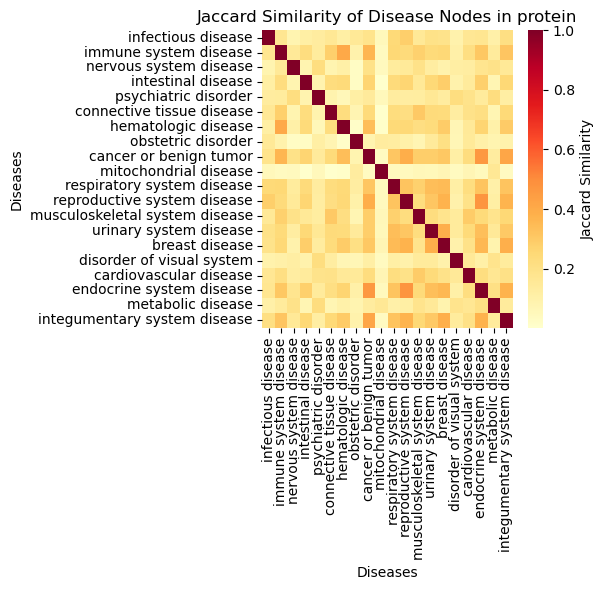

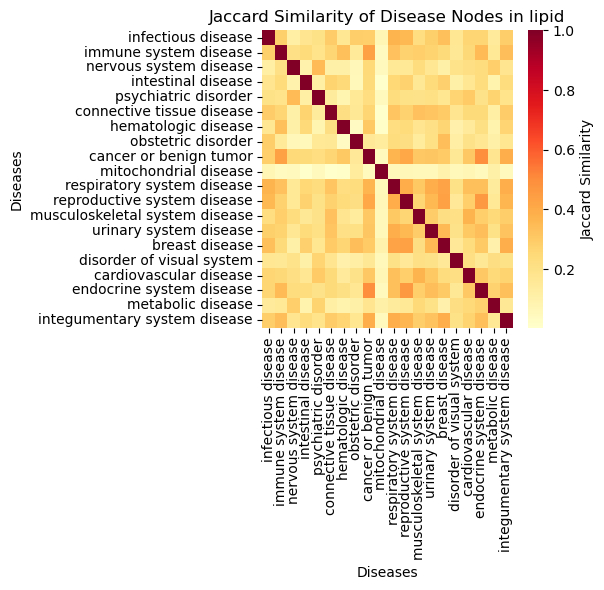

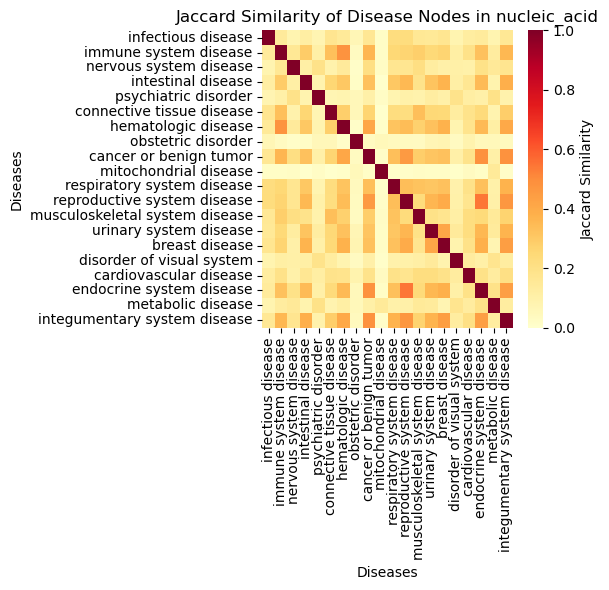

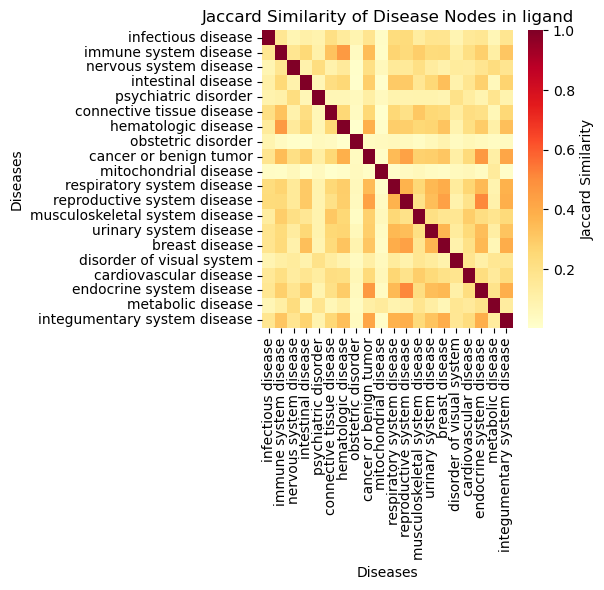

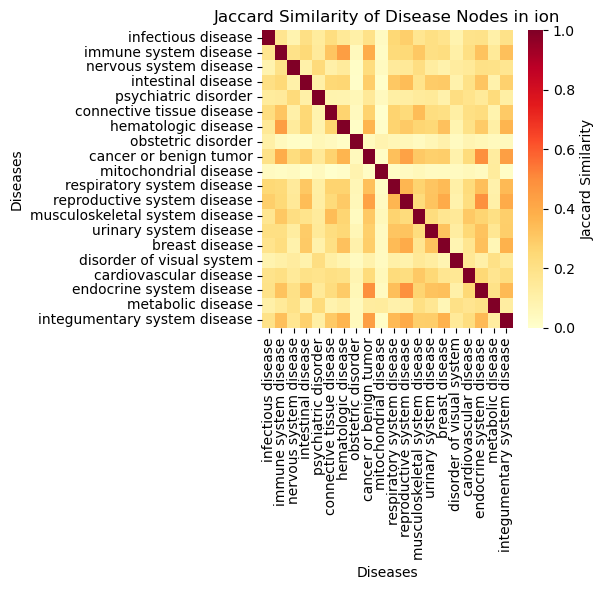

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

def jaccard_similarity(set1, set2):
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union != 0 else 0

for chosen_modality in modalities:
    print(f"Processing modality: {chosen_modality}")
    G = modality_graphs[chosen_modality]['graph'].copy()
    uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
    largest_component = modality_graphs[chosen_modality]['largest_component']
    adjacency_matrix = modality_graphs[chosen_modality]['adjacency_matrix']

    disease_nodes = {}
    for chosen_disease in tqdm(top_level_diseases, desc=f"Collecting disease nodes for {chosen_modality}", total=len(top_level_diseases)):
        disease_prots = set(uniprots_in_modality[chosen_modality]) & set(disease_associations[disease_associations.diseaseId == chosen_disease].uniprot_targetId)
        disease_nodes[chosen_disease] = set([uniprot_to_node_idx[x] for x in disease_prots if x in uniprot_to_node_idx])

    # Calculate Jaccard similarities
    num_diseases = len(top_level_diseases)
    jaccard_matrix = np.zeros((num_diseases, num_diseases))

    for i, disease1 in enumerate(top_level_diseases):
        for j, disease2 in enumerate(top_level_diseases):
            jaccard_matrix[i, j] = jaccard_similarity(disease_nodes[disease1], disease_nodes[disease2])

    # Create heatmap
    plt.figure(figsize=(6,6))
    sns.heatmap(jaccard_matrix, xticklabels=[disease_id_to_name[d] for d in top_level_diseases], 
                yticklabels=[disease_id_to_name[d] for d in top_level_diseases],
                cmap='YlOrRd', annot=False, fmt='.2f', cbar_kws={'label': 'Jaccard Similarity'})

    plt.title(f'Jaccard Similarity of Disease Nodes in {chosen_modality}')
    plt.xlabel('Diseases')
    plt.ylabel('Diseases')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()

TO DO 
* analyse intra-disease vs inter-disease edge distance
* or embedding distance
* or plot it in Gephi

In [5]:
sample_size = 100

distances = defaultdict(list)
for i, disease in enumerate(top_level_diseases):
    print(f"Calculating distances for disease '{disease}' ({i+1}/{len(top_level_diseases)})")
    for modality in modalities:
        G = modality_graphs[modality]["graph"]
        in_disease = set(uniprots_in_modality[modality]) & set(disease_associations[disease_associations.diseaseId == disease].uniprot_targetId)
        in_disease_nodes = [modality_graphs[modality]['uniprot_to_node_idx'][x] for x in in_disease]
        out_disease_nodes = set(modality_graphs[modality]['largest_component']) - set(in_disease_nodes)

        if len(in_disease_nodes) > 1:
            in_pairs = [random.sample(in_disease_nodes, 2) for _ in range(sample_size)]
            in_distances = []
            for in_pair in tqdm(in_pairs, desc=f"Calculating intra-disease path distances for disease '{disease}' and modality '{modality}'", total=sample_size):
                in_distance = nx.shortest_path_length(G, source=in_pair[0], target=in_pair[1])
                in_distances.append(in_distance)
        
        if len(in_disease_nodes) > 0 and len(out_disease_nodes) > 0:
            out_pairs = [(random.choice(list(in_disease_nodes)), random.choice(list(out_disease_nodes))) for _ in range(sample_size)]
            out_distances = []
            for out_pair in tqdm(out_pairs, desc=f"Calculating inter-disease path distances for disease '{disease}' and modality '{modality}'", total=sample_size):
                out_distance = nx.shortest_path_length(G, source=out_pair[0], target=out_pair[1])
                out_distances.append(out_distance)
        
        distances[(disease, modality)] = {
            "intra_disease": in_distances,
            "inter_disease": out_distances,
        }

Calculating distances for disease 'EFO_0005741' (1/20)


Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 51.29it/s]
Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 53.98it/s]
Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 142.66it/s]
Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 126.95it/s]
Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 150.44it/s]
Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 117.00it/s]
Calculating intra-disease path distances for disease 'EFO_0005741' and modality 'ligand': 100%|██████████| 100/100 [00:00<00:00, 190.66it/s]
Cal

Calculating distances for disease 'EFO_0000540' (2/20)


Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 59.21it/s]
Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 59.80it/s]
Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 132.80it/s]
Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 141.64it/s]
Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 120.60it/s]
Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 112.89it/s]
Calculating intra-disease path distances for disease 'EFO_0000540' and modality 'ligand': 100%|██████████| 100/100 [00:00<00:00, 222.01it/s]
Cal

Calculating distances for disease 'EFO_0000618' (3/20)


...

Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 52.72it/s]
Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 52.15it/s]
Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 145.01it/s]
Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 137.93it/s]
Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 139.48it/s]
Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 127.15it/s]
Calculating intra-disease path distances for disease 'EFO_0001379' and modality 'ligand': 100%|██████████| 100/100 [00:00<00:00, 175.78it/s]
Cal

Calculating distances for disease 'EFO_0000589' (19/20)


Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 58.68it/s]
Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 55.47it/s]
Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 133.68it/s]
Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 141.62it/s]
Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 127.20it/s]
Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 120.49it/s]
Calculating intra-disease path distances for disease 'EFO_0000589' and modality 'ligand': 100%|██████████| 100/100 [00:00<00:00, 199.17it/s]
Cal

Calculating distances for disease 'EFO_0010285' (20/20)


Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 55.63it/s]
Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'protein': 100%|██████████| 100/100 [00:01<00:00, 57.93it/s]
Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 136.43it/s]
Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'lipid': 100%|██████████| 100/100 [00:00<00:00, 150.63it/s]
Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 134.32it/s]
Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'nucleic_acid': 100%|██████████| 100/100 [00:00<00:00, 109.18it/s]
Calculating intra-disease path distances for disease 'EFO_0010285' and modality 'ligand': 100%|██████████| 100/100 [00:00<00:00, 177.44it/s]
Cal

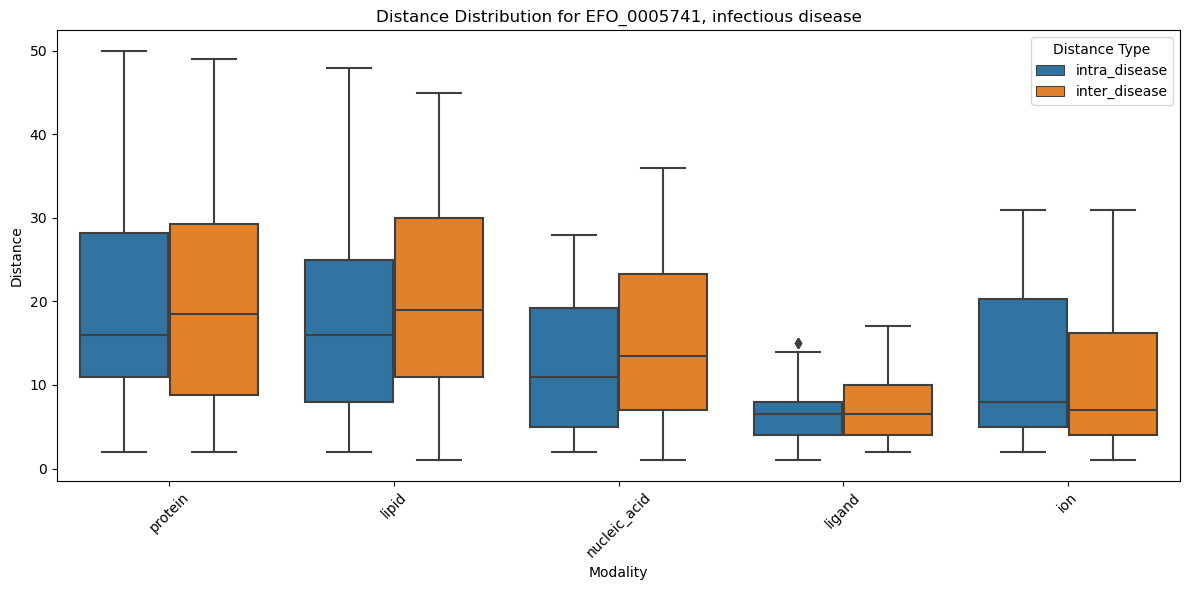

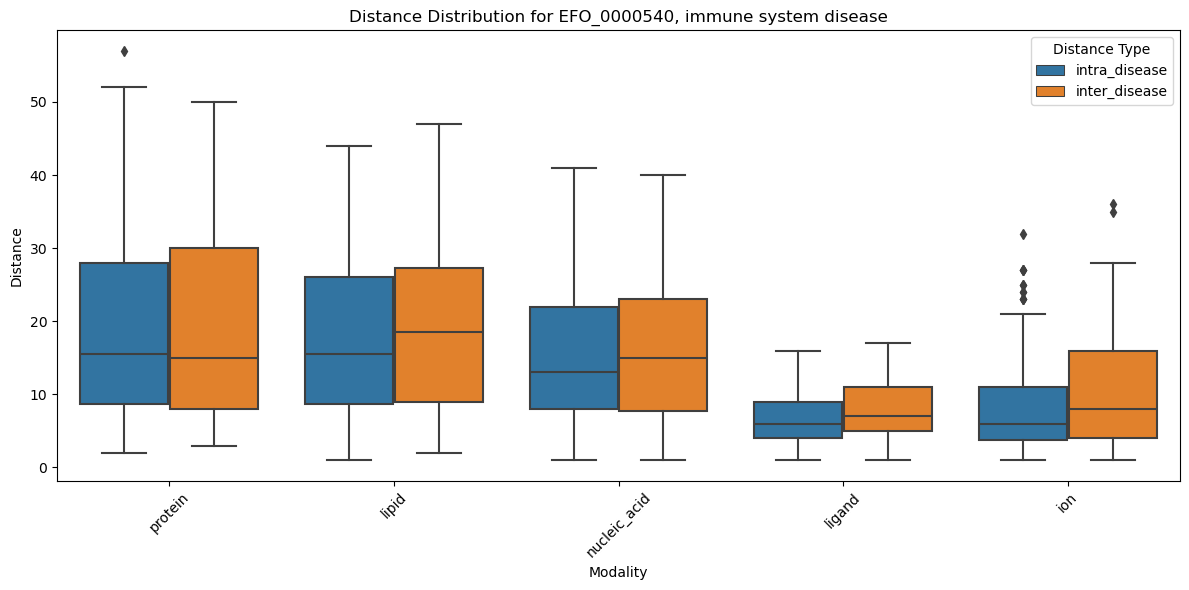

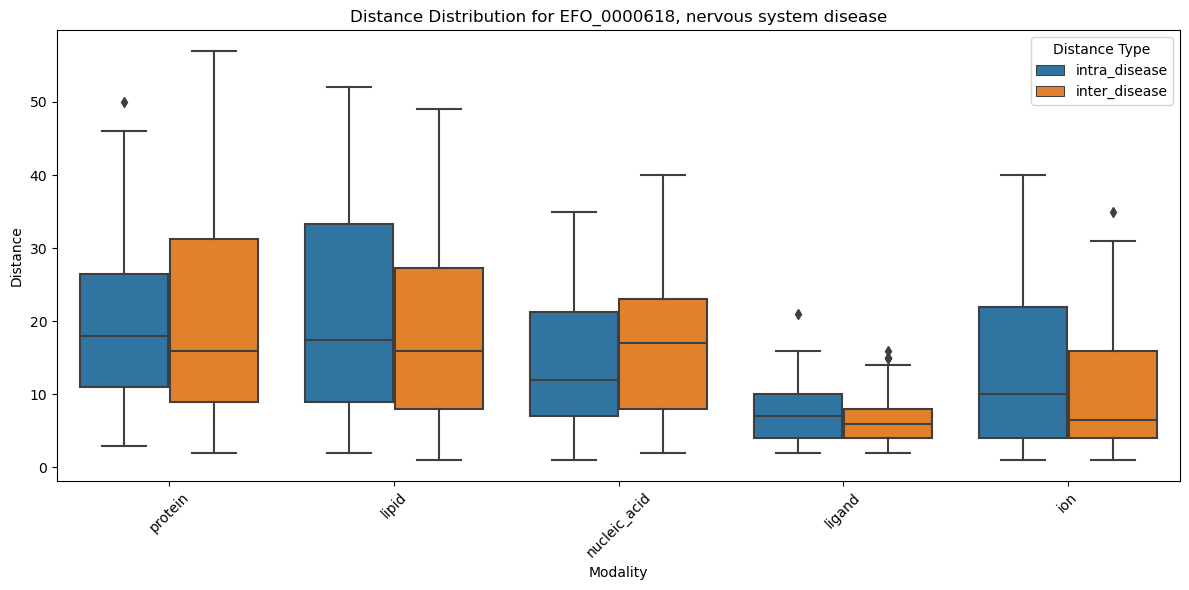

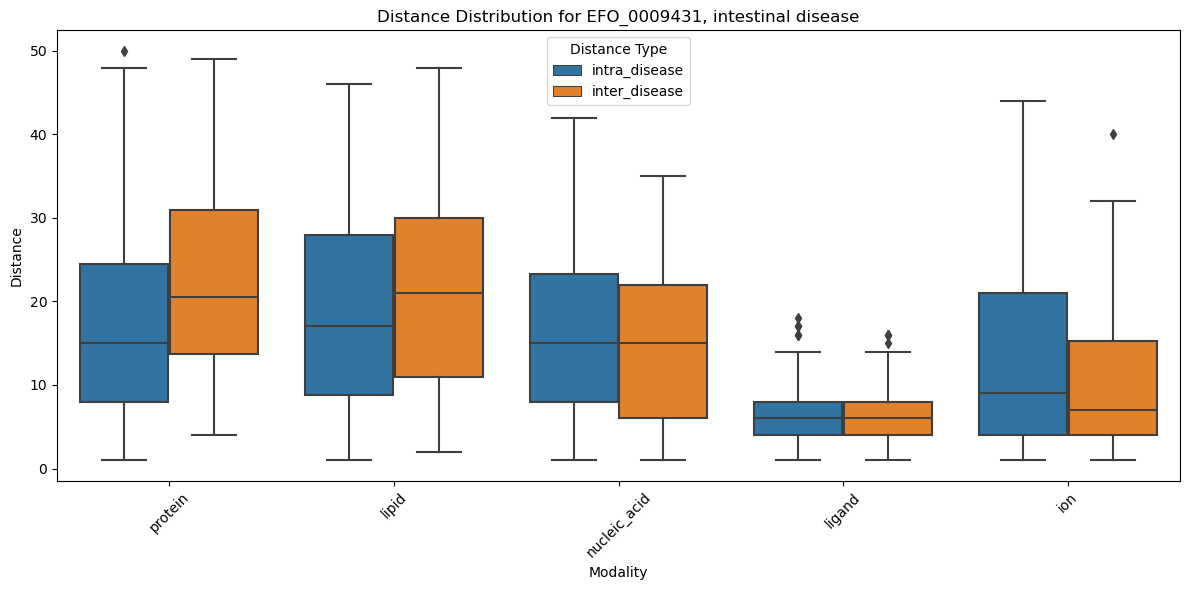

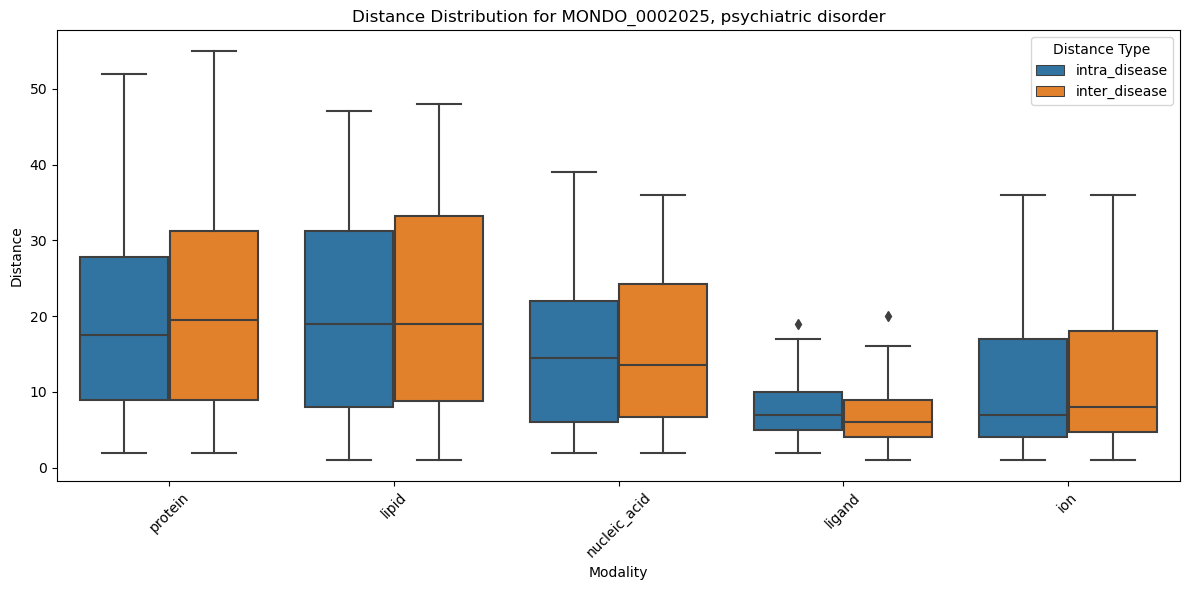

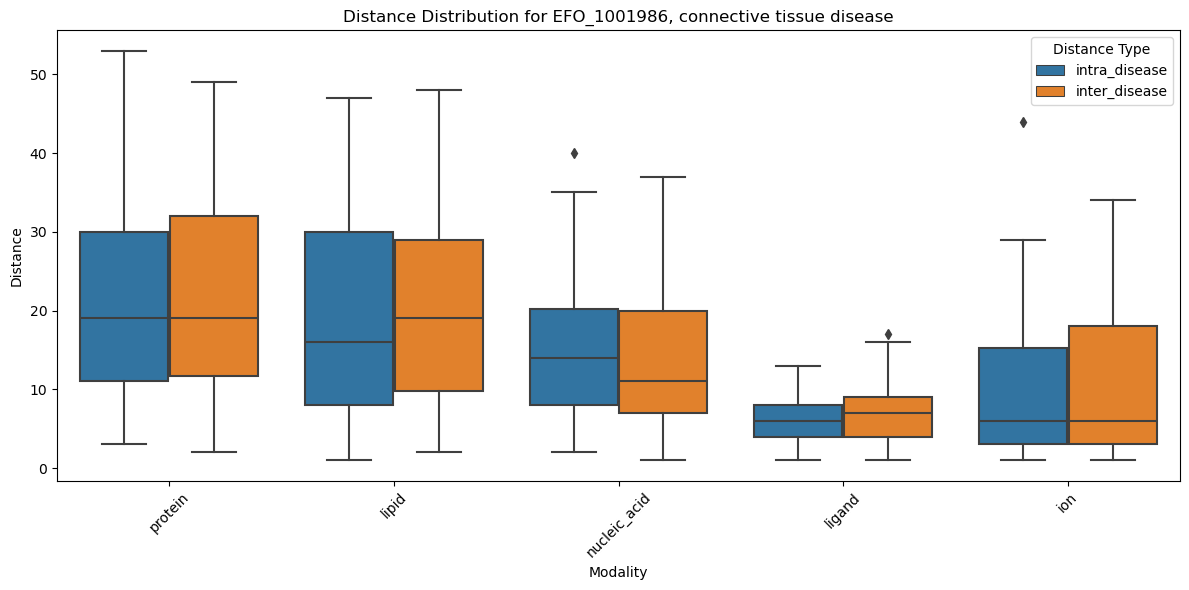

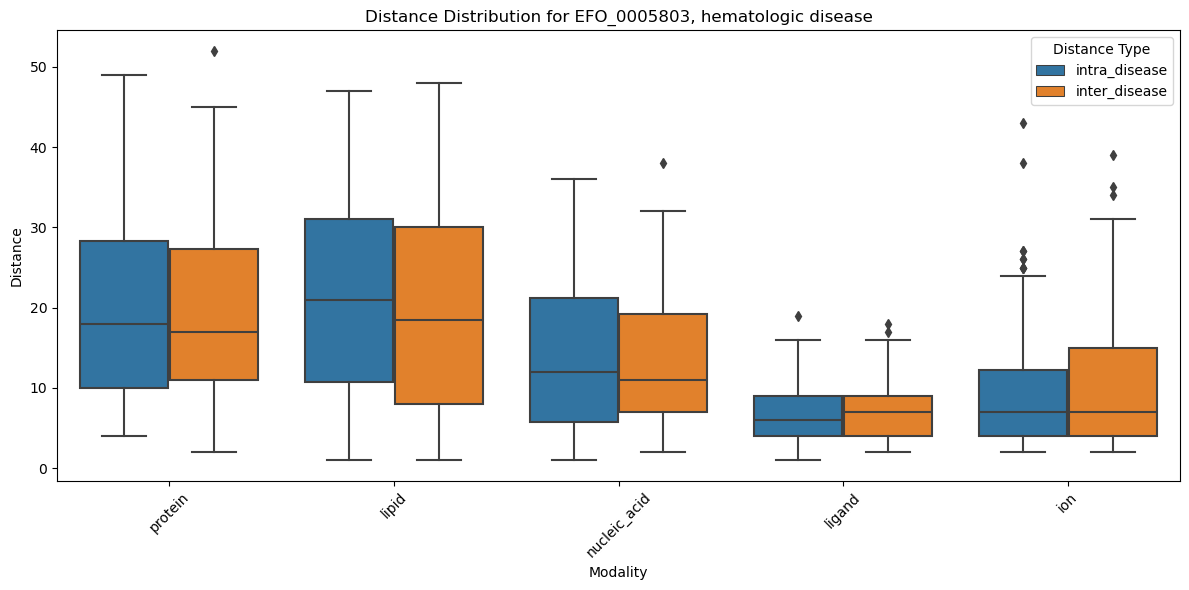

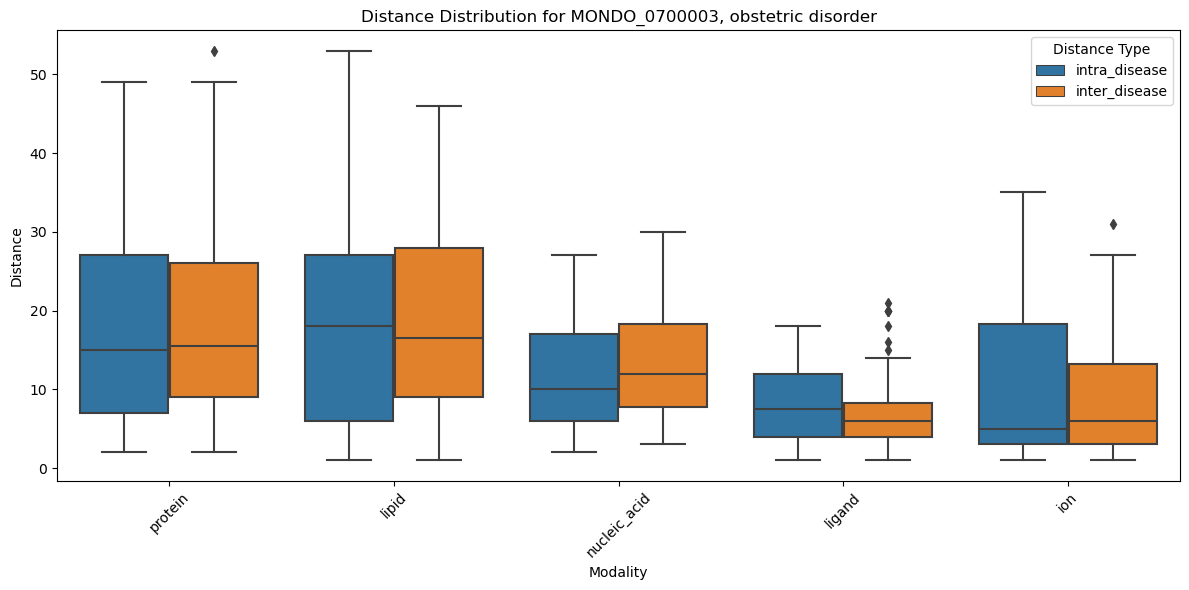

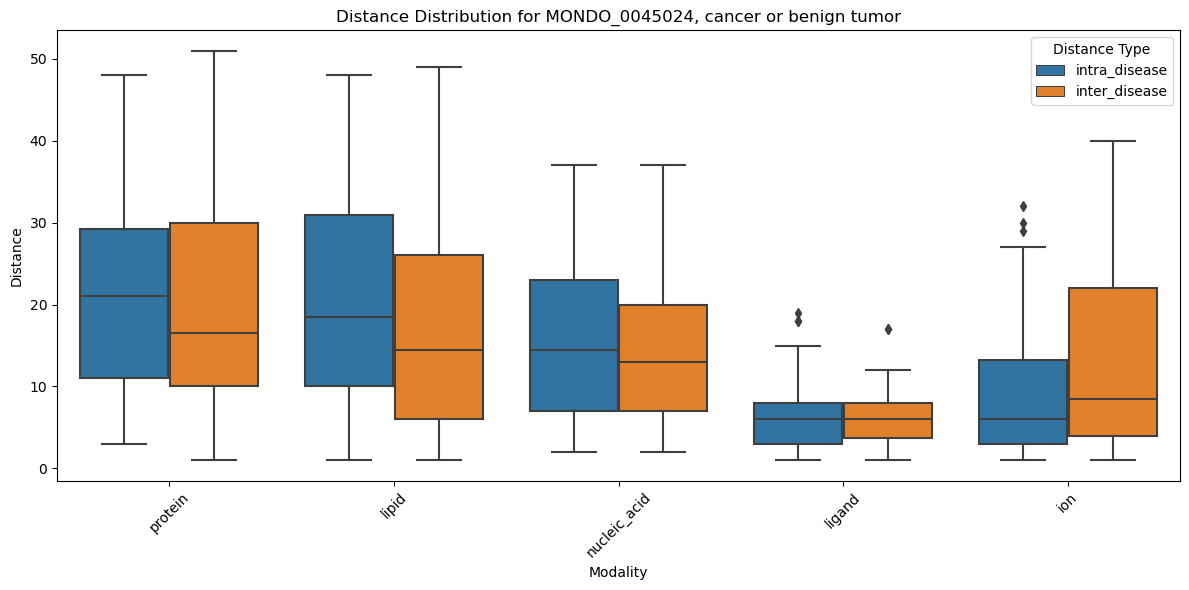

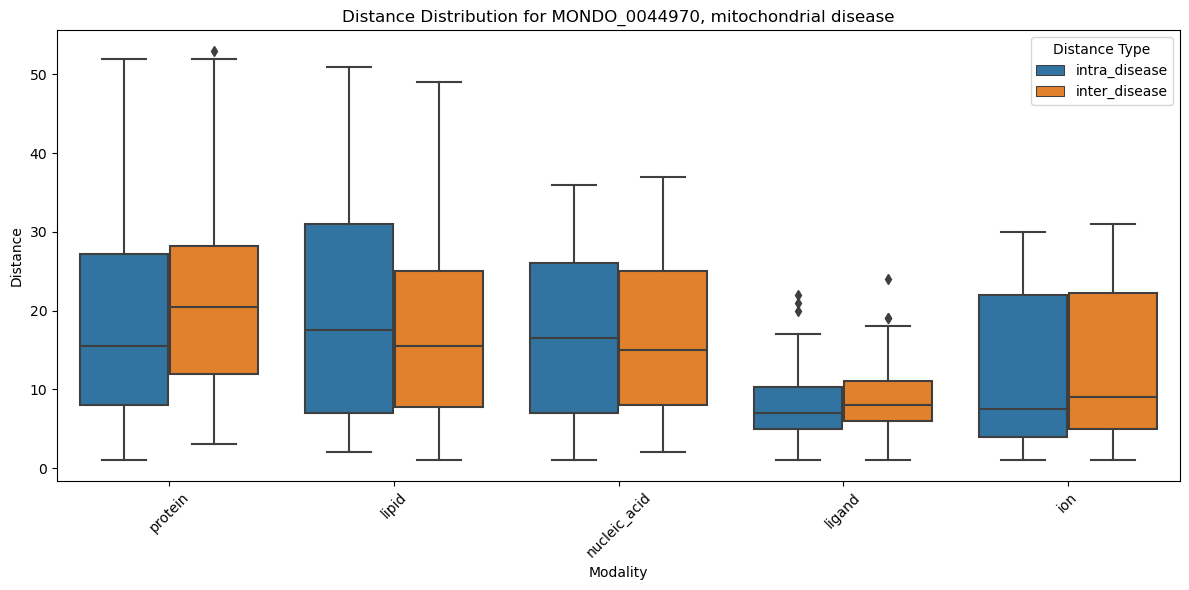

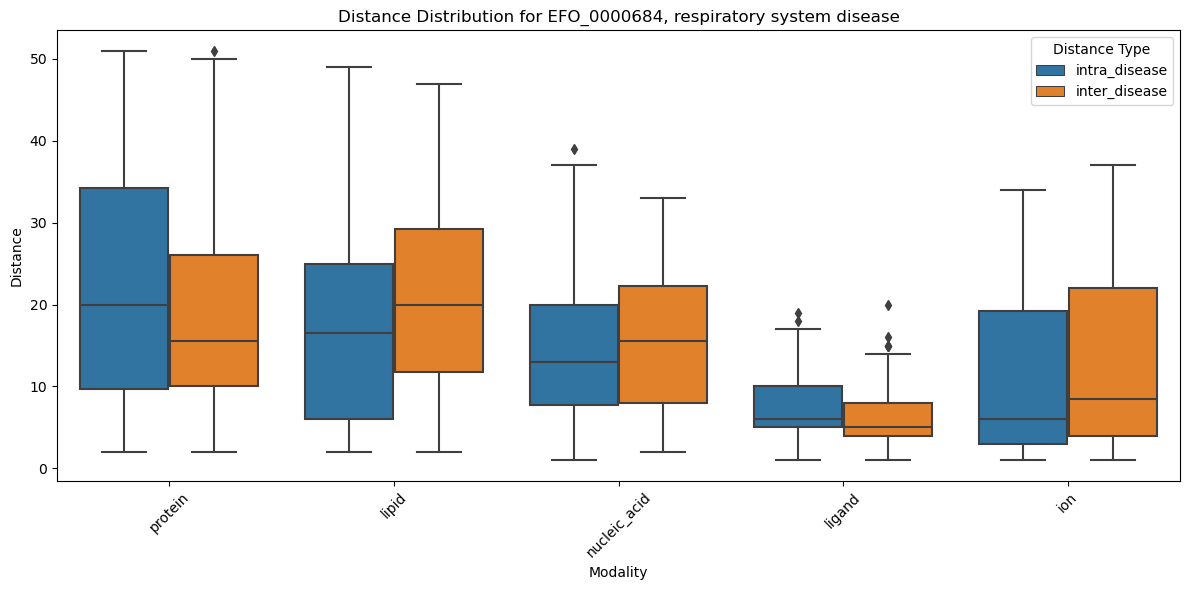

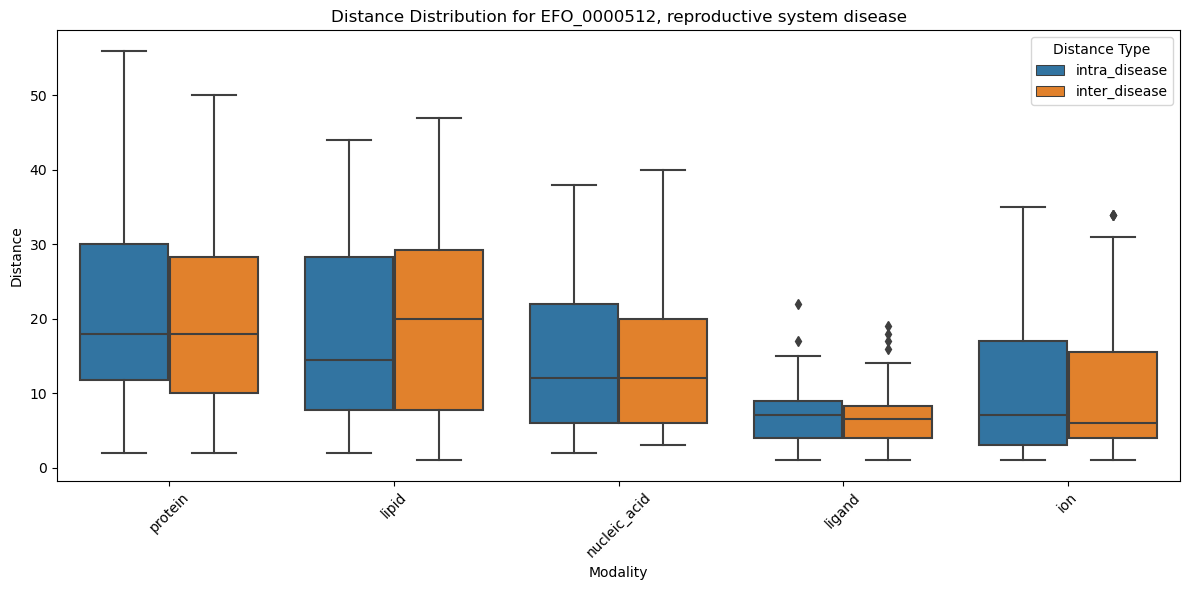

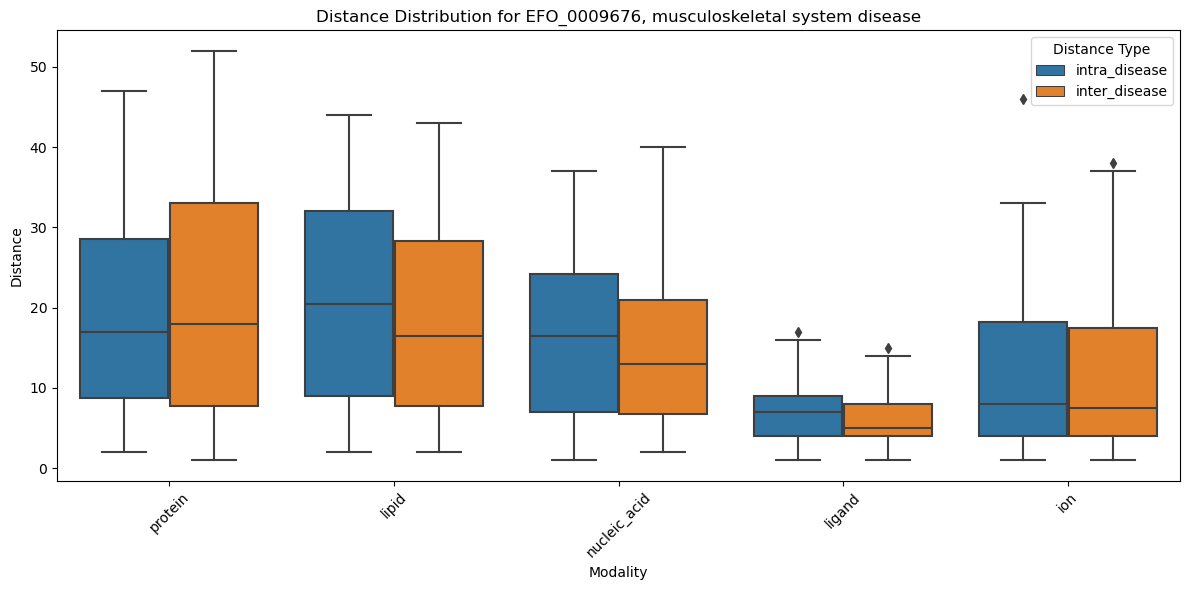

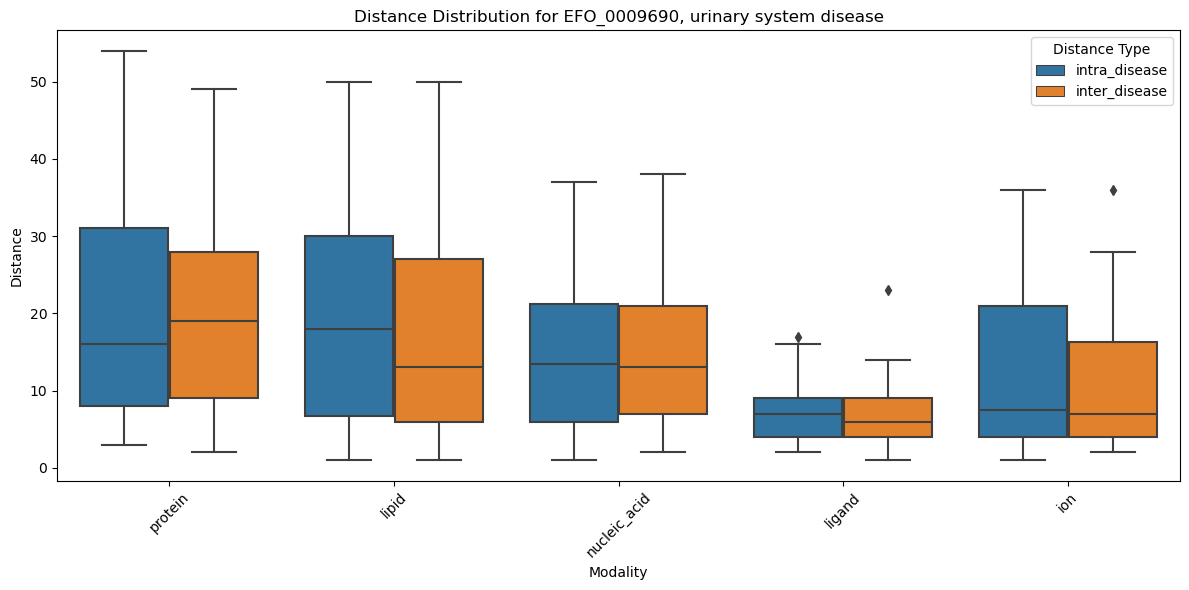

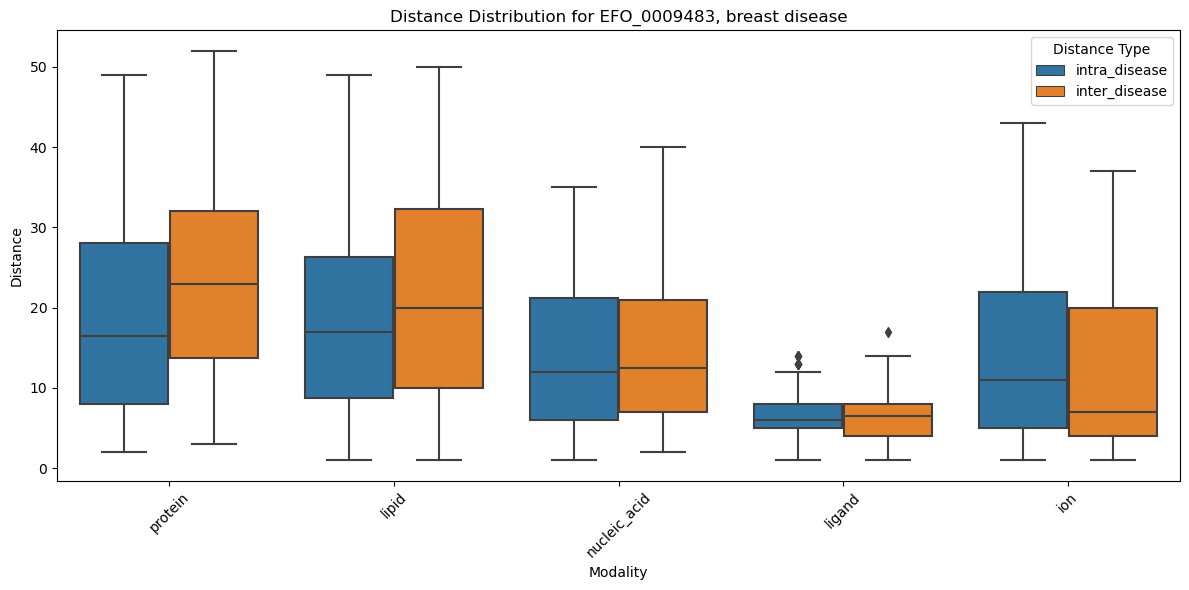

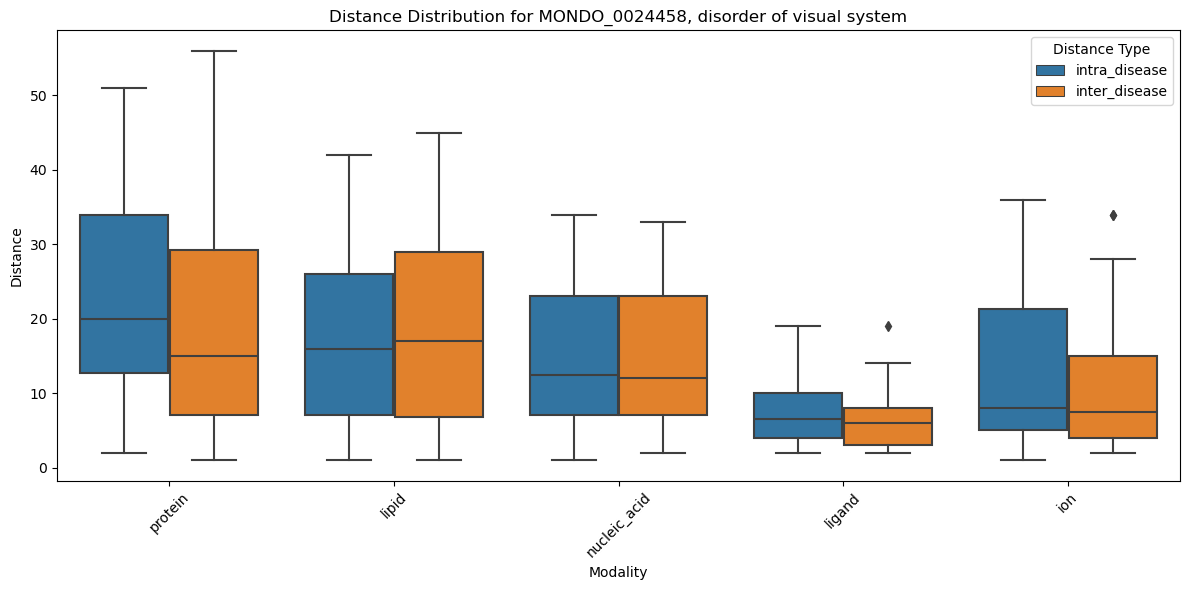

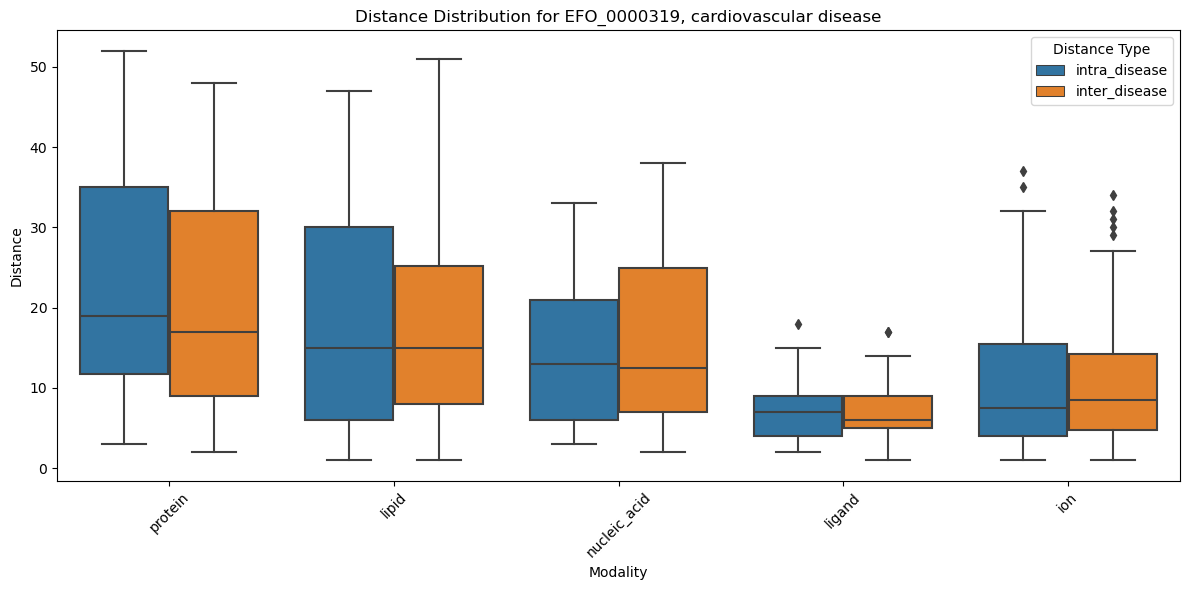

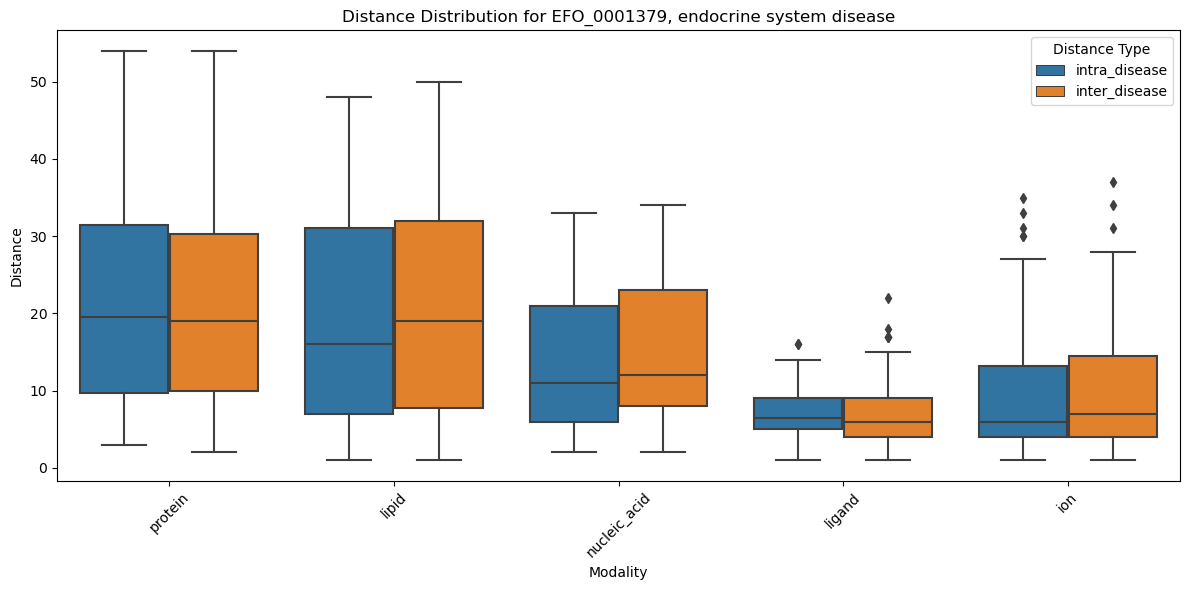

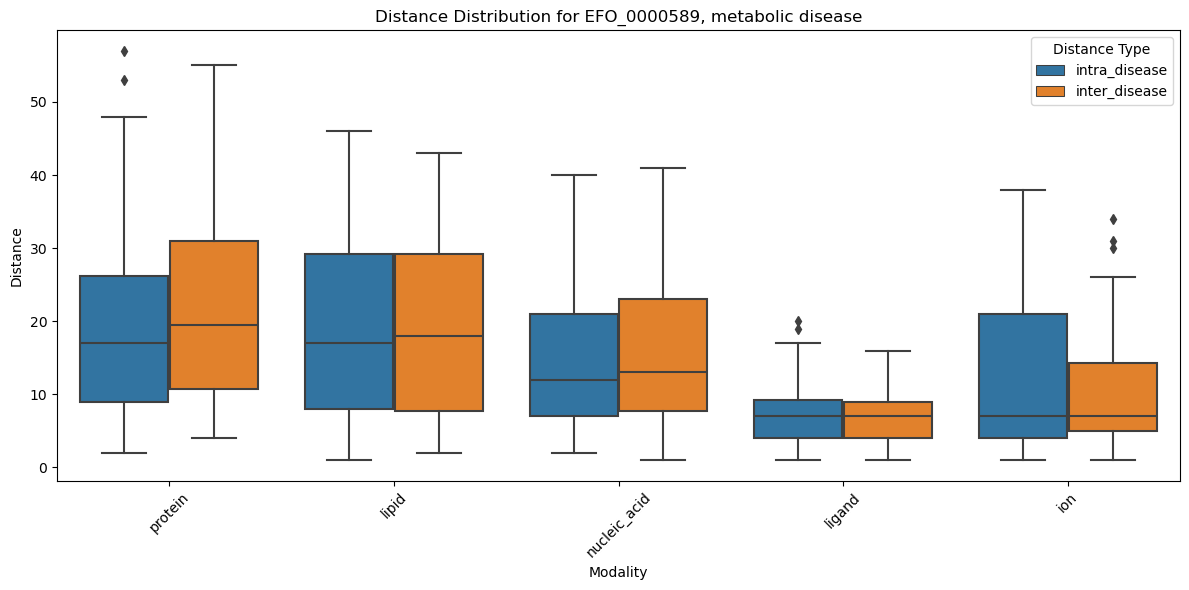

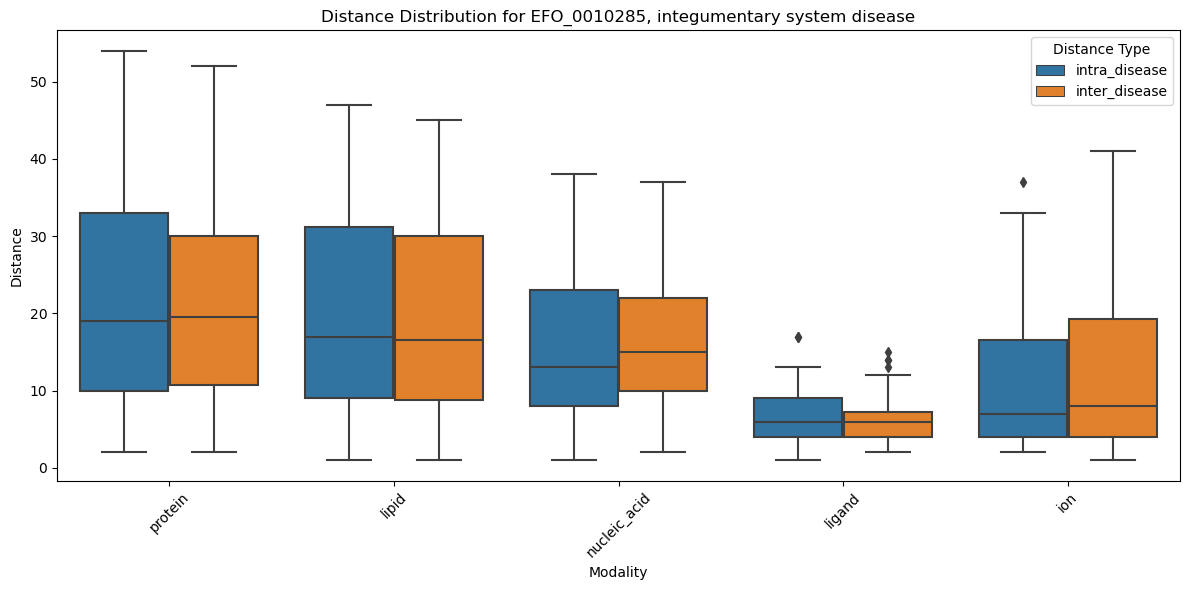

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare the data for plotting
plot_data = []
for (disease, modality), data in distances.items():
    for distance_type in ['intra_disease', 'inter_disease']:
        if data[distance_type]:
            plot_data.extend([
                {'Disease': disease, 'Modality': modality, 'Distance Type': distance_type, 'Distance': d}
                for d in data[distance_type]
            ])

# Convert to DataFrame
df = pd.DataFrame(plot_data)

# Create a plot for each disease
for disease in top_level_diseases:
    # Filter data for the current disease
    disease_data = df[df['Disease'] == disease]
    
    # Set up the plot
    plt.figure(figsize=(12, 6))
    
    # Create the box plot
    sns.boxplot(x='Modality', y='Distance', hue='Distance Type', data=disease_data)
    
    # Customize the plot
    plt.title(f'Distance Distribution for {disease}, {disease_id_to_name[disease]}')
    plt.xlabel('Modality')
    plt.ylabel('Distance')
    plt.xticks(rotation=45)
    plt.legend(title='Distance Type')
    
    # Adjust layout and display
    plt.tight_layout()
    plt.show()

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


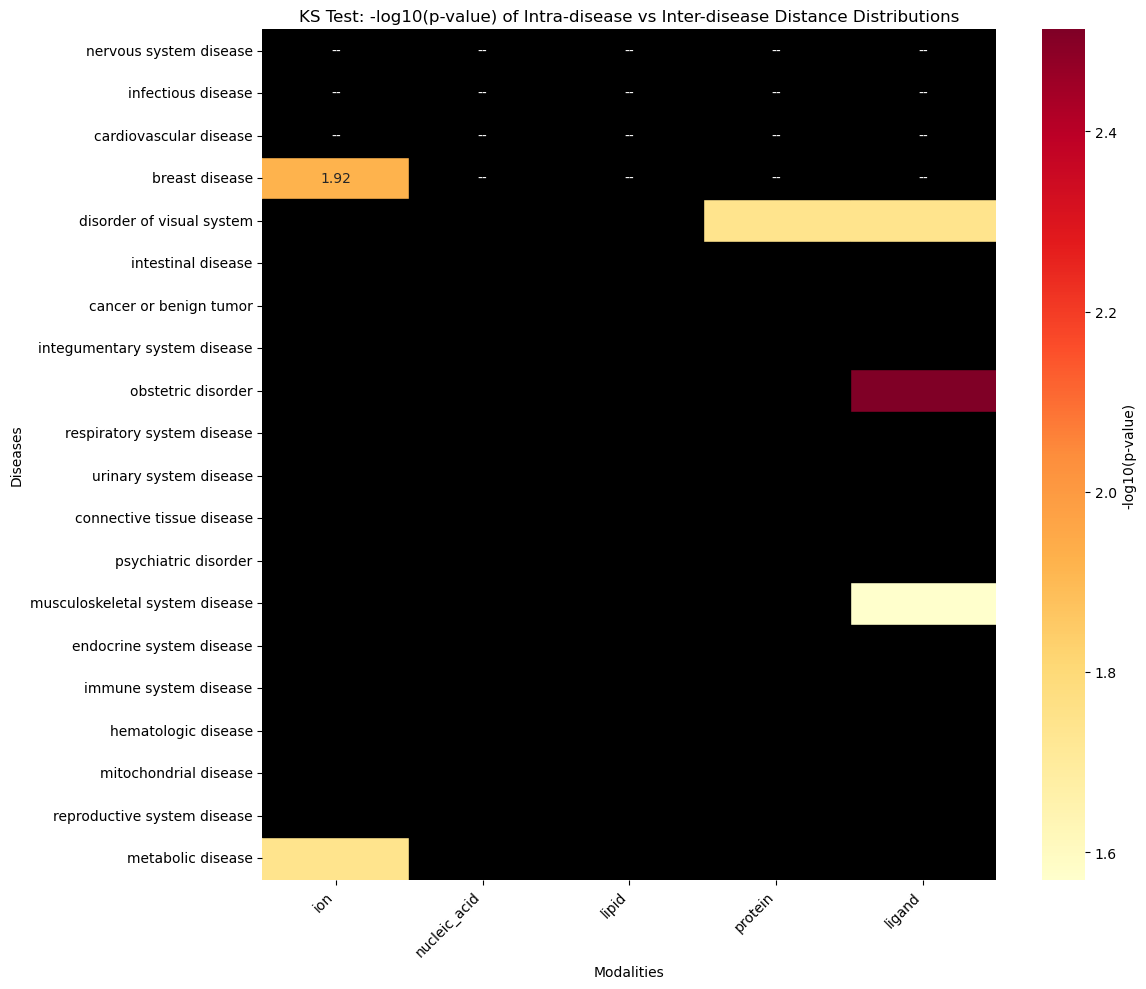

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# Function to compute one-sided KS test p-value
def ks_pvalue(intra, inter):
    if len(intra) > 0 and len(inter) > 0:
        _, p_value = stats.ks_2samp(intra, inter, alternative='less')
        return p_value
    else:
        return np.nan

# Prepare data for the heatmap
diseases = list(set(d for d, _ in distances.keys()))
modalities = list(set(m for _, m in distances.keys()))

pvalue_matrix = np.zeros((len(diseases), len(modalities)))

for i, disease in enumerate(diseases):
    for j, modality in enumerate(modalities):
        intra = distances.get((disease, modality), {}).get('intra_disease', [])
        inter = distances.get((disease, modality), {}).get('inter_disease', [])
        pvalue_matrix[i, j] = ks_pvalue(intra, inter)

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(pvalue_matrix, index=diseases, columns=modalities)

# Create a mask for non-significant p-values
mask = df > 0.05

# Convert p-values to -log10(p-value)
df = -np.log10(df)

# Create the heatmap
plt.figure(figsize=(12, 10))
ax = sns.heatmap(df, cmap='YlOrRd', mask=mask, 
                 annot=True, fmt='.2f', cbar_kws={'label': '-log10(p-value)'})

# Color non-significant cells black
for i in range(len(diseases)):
    for j in range(len(modalities)):
        if mask.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='black'))

plt.title('KS Test: -log10(p-value) of Intra-disease vs Inter-disease Distance Distributions')
plt.xlabel('Modalities')
plt.ylabel('Diseases')
plt.xticks(rotation=45, ha='right')

disease_names = [disease_id_to_name[d] for d in diseases]
plt.yticks([x+0.5 for x in range(len(diseases))], disease_names, rotation=0)

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()